# MiniBatch K-Means - Instacart (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    minibatch_kmeans_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [8]:
df_scaled = pd.read_csv("../../../scaled_data/instacart_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/instacart_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["user_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 206,209
Variables de clustering: 3


,recency,frequency,avg_basket_size
0,-0.286895,-0.070348,-0.578158
1,1.212334,0.316791,0.820566
2,-0.568000,0.138171,-0.236083
3,1.212334,-0.826933,-1.313020
4,-1.036509,-1.054508,0.139108


## Evaluación del número de clusters


In [9]:
resultados_minibatch = minibatch_kmeans_metrics(X)
display(resultados_minibatch)

,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos
0,2,0.325258,105919.416856,1.278911,408742.687822,0.078324
1,3,0.306759,93564.096867,1.263752,324887.727719,0.064015
2,4,0.315253,103513.427021,1.090711,247113.183289,0.304421
3,5,0.304326,98993.819699,1.067747,212075.099884,0.431481
4,6,0.287861,92542.785246,1.110500,191238.961903,0.438355
5,7,0.287363,88688.845444,1.083745,173472.413504,0.083039
6,8,0.284887,90539.561492,1.089686,152061.334109,0.308472
7,9,0.282639,87440.639855,1.070433,140993.880428,0.318882
8,10,0.276864,87796.920560,1.041496,128326.131739,0.516013


In [ ]:
tabla_metricas = save_clustering_metrics(
    resultados_minibatch,
    model_name="minibatch",
    dataset_name="instacart",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

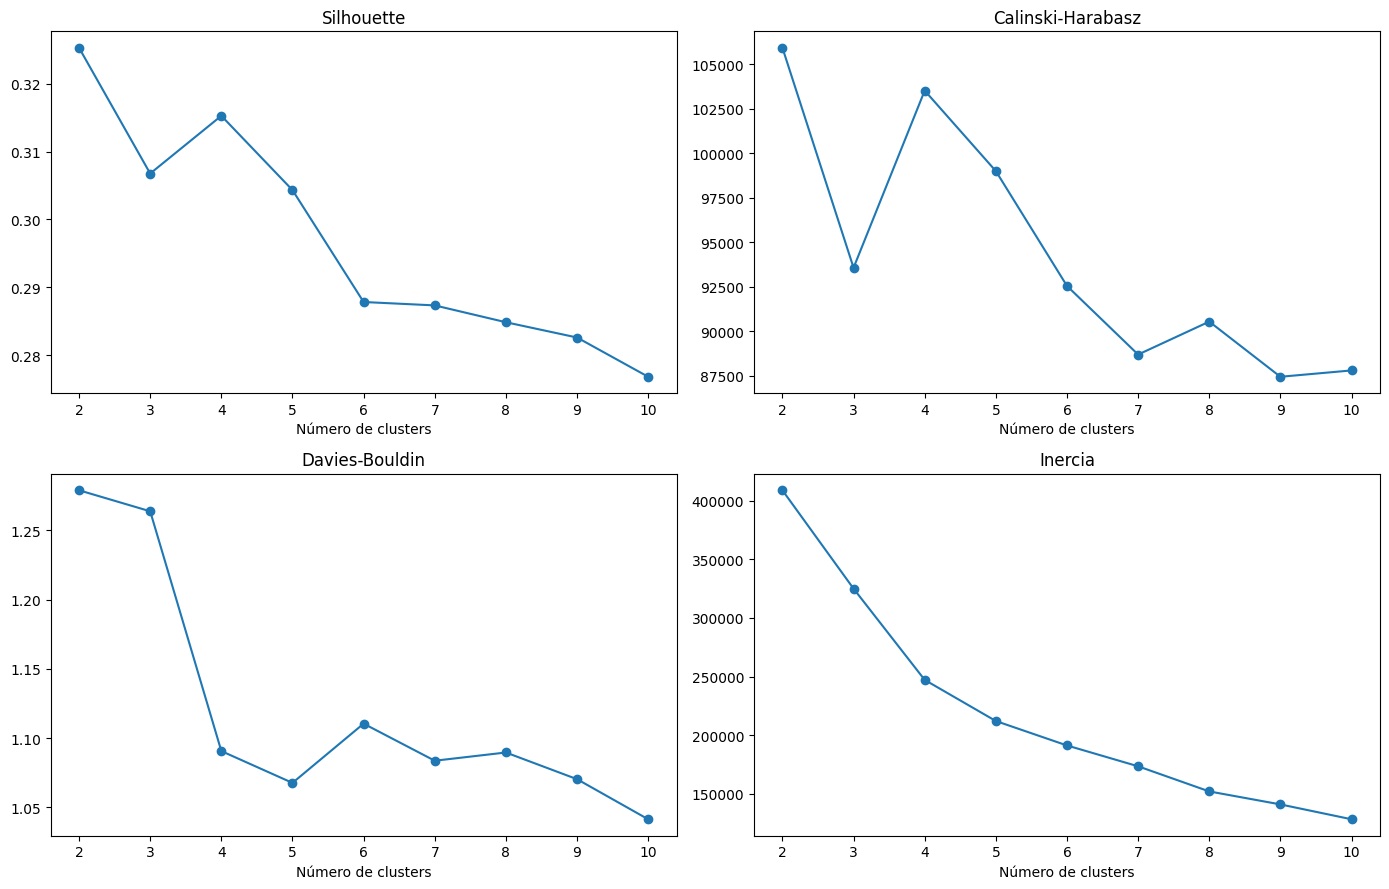

In [10]:
plot_clustering_metrics(
    resultados_minibatch,
    fourth_metric="inertia",
    fourth_title="Inercia",
)

## Ajuste final y perfil de los clusters


In [11]:
modelo, labels = fit_clustering_model(
    model_name="minibatch",
    k=2,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    101686
1    104523
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    49.31
1    50.69
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,26.460,8.184,9.472
1,7.919,22.795,10.419


- Cluster 0 - Clientes menos recientes y moderados (49,31%): presentan alta recencia, baja frecuencia y cestas ligeramente menores.
- Cluster 1 - Clientes activos y frecuentes (50,69%): compran recientemente, realizan casi tres veces más pedidos y mantienen cestas algo mayores.

In [12]:
modelo, labels = fit_clustering_model(
    model_name="minibatch",
    k=4,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="user_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    40026
1    59315
2    51821
3    55047
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    19.41
1    28.76
2    25.13
3    26.69
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,avg_basket_size
cluster,,,
0,24.958,8.413,3.894
1,27.765,8.962,13.029
2,8.012,37.082,10.511
3,8.306,7.719,10.514


- Cluster 0 - Clientes ocasionales de cesta pequeña (19,41%): presentan alta recencia, baja frecuencia y las cestas más pequeñas.
- Cluster 1 - Clientes ocasionales de cesta grande (28,76%): llevan más tiempo sin comprar y tienen baja frecuencia, pero realizan las cestas más grandes.
- Cluster 2 - Clientes frecuentes y activos (25,13%): destacan por una frecuencia muy elevada y baja recencia, con cestas de tamaño medio.
- Cluster 3 - Clientes recientes de actividad moderada (26,69%): han comprado recientemente, aunque mantienen una frecuencia baja y cestas medias.